In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pathlib
from ttjjana import prepdata
from mmd import mmd_rbf
from sdiffusion2cond import *

# Shape estimation with stable diffusion 

An arbitrary empirical distribution can be learned through a stable diffusion algorithm. 

## Read data and reshape

In [2]:
rawinputs, normedinputs, inputmeans, inputsigma, ncat_per_feature = prepdata()

In [3]:
# this contains how many conditional features are in each category
ncat_per_feature

[0, 0, 0, 0, 3, 2]

In [4]:
normedinputs.shape

(227376, 9)

In [5]:
#conditional dimensions
cdim = np.sum(ncat_per_feature)
M = normedinputs.shape[1] - cdim
if cdim > 0:
    print(f"Conditional dimension: {cdim}")
    isconditional = True
else:
    print("No conditional dimension")
    isconditional = False

Conditional dimension: 5


In [6]:
inputoffset = np.array([0.0]*M + [0.0]*cdim)
normedinputs = normedinputs + inputoffset

In [7]:
featurevars = ['met', 'ht', 'pt5', 'pt6', 'njet', 'nbtag']

In [8]:
normedinputs.shape

(227376, 9)

In [9]:
issignal = (rawinputs['njet']>=9) & (rawinputs['nbtag']>=3) # signal_selection 
isbackground = ~issignal
bkgnormed = normedinputs[isbackground]
bkg = rawinputs[isbackground]
xmax = np.reshape(inputmeans + 5* inputsigma, inputmeans.shape[1])

## Train model

### setup training

In [18]:
# --- Setup Diffusion Model Config ---
config = Config(
    M=M,
    nhidden=512,
    nlayers=2,
    timesteps=400,
    timeembed=16,
    noise_schedule='linear',
    batch_size=128,
    learning_rate=1e-3,
    epochs=1000,
    model_type='SimpleUNet',  # 'SimpleUNet' or 'MingruMLP
    conditional=isconditional,
    conditional_dim=cdim,
    conditional_bkg=[[1., 0., 0.,   1., 0., ],
            [0., 1., 0.,   1., 0., ],
            [0., 0., 1.,   1., 0., ],
            [1., 0., 0.,   0., 1., ],
            [0., 1., 0.,   0., 1., ],
            [0., 0., 1.,   0., 1., ]],
)
scheduler = DiffusionScheduler(config.noise_schedule, config.timesteps, config.device)

Using device: cuda
Automatic Mixed Precision (AMP) enabled: False
DiffusionScheduler initialized on cuda with T=400 (linear)


In [11]:
data_cpu = torch.from_numpy(bkgnormed).float()
data_on_device = None
if config.device.type == 'cuda':
    print(f"Attempting to move dataset ({data_cpu.nelement() * data_cpu.element_size() / 1024**2:.2f} MB) to {config.device}...")
    try:
        data_on_device = data_cpu.to(config.device)
        print(f"Successfully moved dataset to {data_on_device.device}")
    except RuntimeError as e:
        print(f"\n----- ERROR moving full dataset to GPU: {e}. Exiting. -----")
        exit()
else:
    print("Running on CPU, keeping data on CPU.")
    data_on_device = data_cpu

Attempting to move dataset (6.95 MB) to cuda...
Successfully moved dataset to cuda:0


### Training

In [12]:
# --- Training ---
train_model_flag = True
continue_training = True

In [13]:
config_dir = get_config_directory(config)
pathlib.Path(config_dir).mkdir(parents=True, exist_ok=True)
#srcdist = data_on_device[:,:config.M]
srcdist = None
if srcdist is not None:
    model_filename = "model_fm.pth" # Flow Matching model filename
    training_plotfilename = "training_loss_fm.png" # Training loss plot filename
else:
    model_filename = "model_fm_normal.pth"
    training_plotfilename = "training_loss_fm_normal.png" # Training loss plot filename

model_path = pathlib.Path(config_dir) / model_filename

if continue_training and model_path.exists():
    print(f"Continuing training from checkpoint: {model_path}")
    if config.model_type == 'MingruMLP':
        # Load the MingruMLP model
        trained_model = load_model(MingruMLP, config, filename=model_filename)
    else:
        trained_model = load_model(SimpleUNet, config, filename=model_filename)
else:
    trained_model = None

if train_model_flag:
    print("\n--- Starting Flow Matching Training ---")
    # Call the flow matching training function
    # Adjusted return signature - no MMD history
    trained_model, epoch_losses = train_ddpm(data_on_device, config, srcdist, v_net=trained_model)

    if trained_model:
        save_model(trained_model, config, filename=model_filename)
        if epoch_losses:
            # Use updated plotting function signature
            plot_training_loss(epoch_losses, config, training_plotfilename)

    else:
        print("Training failed, model not saved.")
else:
    #if not os.path.exists(model_path):
    if not model_path.exists():
        print(f"\nModel file {model_path} not found. Cannot perform sampling.")
    else:
        print("\n--- Loading Model for Flow Matching Sampling ---")
        # Load the velocity network model
        #trained_model = load_model(MingruMLP, config, filename=model_filename)
        trained_model = load_model(SimpleUNet, config, filename=model_filename)


--- Starting Flow Matching Training ---
--- Preparing Data and Loaders ---
Generating default source distribution (Gaussian)
Source DataLoader created (shuffle=True)
Creating target DataLoaders for 6 categories...
  - Created DataLoader for category 0 with 63216 samples.
  - Created DataLoader for category 1 with 49685 samples.
  - Created DataLoader for category 2 with 55757 samples.
  - Created DataLoader for category 3 with 17007 samples.
  - Created DataLoader for category 4 with 16766 samples.
  - No samples found for category 5 ([0.0, 0.0, 1.0, 0.0, 1.0]). Skipping DataLoader creation.
--- Initializing Training Components ---
Initializing VelocityField model.


d:\work\sdiffusion\sdiffusion2cond.py:468: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=config.use_amp)


Initializing Diffusion Scheduler...
DiffusionScheduler initialized on cuda with T=400 (linear)
--- Starting Flow Matching Training (1000 epochs) ---


Training FM:   0%|          | 0/1000 [00:00<?, ?epoch/s]d:\work\sdiffusion\sdiffusion2cond.py:572: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=config.use_amp):
d:\work\sdiffusion\sdiffusion2cond.py:572: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=config.use_amp):


Processing approximately 1581 batches per epoch.


Training FM: 100%|██████████| 1000/1000 [1:41:27<00:00,  6.09s/epoch, avg_loss=0.323415]




Training finished.
Model saved to DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_MLP\model_fm_normal.pth
Plot saved to DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_MLP\training_loss_fm_normal.png
Plot saved to DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_MLP\training_loss_fm_normal.png


### setup for plots

In [15]:
condlist = [
            [[1., 0., 0.,   1., 0., ]],
            [[0., 1., 0.,   1., 0., ]],
            [[0., 0., 1.,   1., 0., ]],
            [[1., 0., 0.,   0., 1., ]],
            [[0., 1., 0.,   0., 1., ]],
            [[0., 0., 1.,   0., 1., ]]
        ]
select0 = (rawinputs['njet']==7) & (rawinputs['nbtag']==2)
select1 = (rawinputs['njet']==8) & (rawinputs['nbtag']==2)
select2 = (rawinputs['njet']>=9) & (rawinputs['nbtag']==2)
select3 = (rawinputs['njet']==7) & (rawinputs['nbtag']>=3)
select4 = (rawinputs['njet']==8) & (rawinputs['nbtag']>=3)
select5 = (rawinputs['njet']>=9) & (rawinputs['nbtag']>=3)
select_data = [select0, select1, select2, select3, select4, select5]

plottextlist=[
    f'$N_j=7, N_b=2$',
    f'$N_j=8, N_b=2$',
    f'$N_j\geq 9, N_b=2$',
    f'$N_j=7, N_b\geq 3$',
    f'$N_j=8, N_b\geq 3$',
    f'$N_j\geq 9, N_b\geq 3$'
]
njlist = [7, 8, 9, 7, 8, 9]
nblist = [2, 2, 2, 3, 3, 3]

In [15]:
cond = torch.tensor(condlist[0]*4000).to(config.device).float()

In [16]:
gensamples = sample(trained_model, config, scheduler, 4000, cond)

Sampling Progress:   0%|          | 0/400 [00:00<?, ?it/s]d:\work\sdiffusion\sdiffusion2cond.py:426: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=config.use_amp):
Sampling Progress:  18%|█▊        | 72/400 [00:00<00:00, 683.29it/s]d:\work\sdiffusion\sdiffusion2cond.py:426: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=config.use_amp):
                                                                     

In [17]:
gensamples= gensamples.numpy()

In [18]:
gensamples

array([[ 0.76838624,  0.08478555, -0.9266069 , -0.91762483],
       [ 3.5713017 ,  1.3089269 ,  0.18442294, -0.9591967 ],
       [ 0.68714505, -0.61792135, -0.45016822, -0.750422  ],
       ...,
       [ 0.5125962 ,  0.3816194 ,  0.43615186, -0.471559  ],
       [-0.47458705, -0.41785917,  0.46691704, -1.0463439 ],
       [-0.87621164, -0.9417331 , -0.44285718, -0.7175217 ]],
      shape=(4000, 4), dtype=float32)

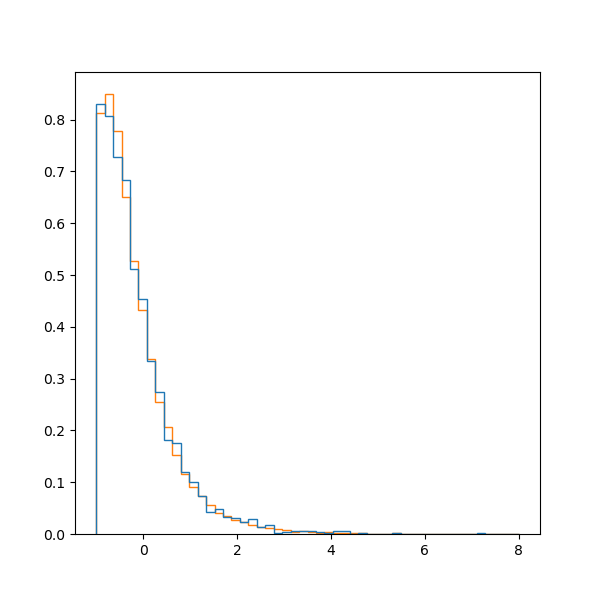

In [19]:
%matplotlib widget
plt.figure(figsize=(6, 6))
plt.hist((gensamples[:,2],normedinputs[select0][:,2]), bins=50, density=True, range=(-1, 8), histtype='step', label='Flow Matching')
plt.show()

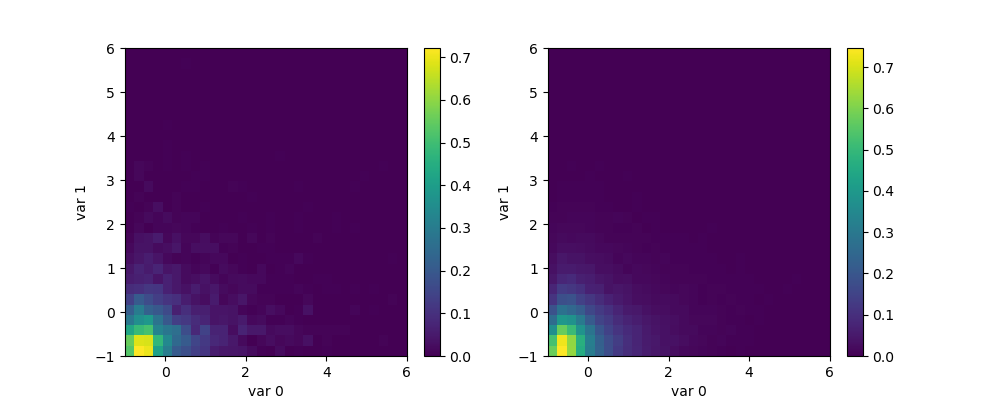

In [20]:
plt.close()
fig, ax = plt.subplots(1, 2 ,figsize=(10, 4))
plt.sca(ax[0])
plt.hist2d(gensamples[:,0],gensamples[:,1], bins=30, range=((-1, 6), (-1,6)), density=True)
plt.xlabel('var 0')
plt.ylabel('var 1')    
plt.colorbar()
plt.sca(ax[1])
plt.hist2d(normedinputs[select0][:,0],normedinputs[select0][:,1], bins=30, range=((-1, 6), (-1, 6)), density=True)
plt.xlabel('var 0')
plt.ylabel('var 1')
plt.colorbar()
plt.show()

## Create fake data and full set of plots

In [21]:
fakedatalist = []
for cond, nj, nb in zip(condlist, njlist, nblist):
        condtorch = torch.tensor(cond*40000).to(config.device).float()
        fakedata = sample(trained_model, config, scheduler, 40000, condtorch).cpu().numpy() \
                - inputoffset[:config.M] # remove offset

        # all data
        fakedata = fakedata * inputsigma[:, :config.M] + inputmeans[:, :config.M]
        nfakes = fakedata.shape[0]

        fakedata = np.hstack((fakedata, np.array([nj]*nfakes).reshape((nfakes,1))\
                , np.array([nb]*nfakes).reshape(nfakes,1) )
        )
        fakedatalist.append(fakedata)


### Plot

In [22]:
import matplotlib.gridspec as gridspec

nrow, ncol = 2, 3
labelsindices = [['MET', 'met', 0.0, xmax[0]], ['H_T', 'ht', 0.0, xmax[1]],
    ['p_{T5}', 'pt5', 0.0, xmax[2]], ['p_{T6}', 'pt6', 0.0, xmax[3]]]
nbins = 20
runplots = True
if runplots:
    yscales = ['log', 'linear']
    for yscale in yscales:
        for li in labelsindices:
            pos = featurevars.index(li[1])
            fig = plt.figure(figsize=(3 * ncol, 3.0 * nrow))
            gs = gridspec.GridSpec(nrow * 2, ncol, height_ratios=[4, 1.5] * nrow, hspace=0)
            axes_main = []
            axes_ratio = []
            for iplot, (fakedata, seld, plottext) in enumerate(zip(fakedatalist, select_data, plottextlist)):
                row = iplot // ncol
                col = iplot % ncol
                ax_main = fig.add_subplot(gs[row*2, col])
                ax_ratio = fig.add_subplot(gs[row*2+1, col], sharex=ax_main)
                axes_main.append(ax_main)
                axes_ratio.append(ax_ratio)
                # Main plot
                ax_main.set_yscale(yscale)
                ax_main.set_xlabel("")
                ax_main.tick_params(labelbottom=False)
                input_data = rawinputs[seld]
                data_hist, bin_edges = np.histogram(input_data[li[1]], bins=nbins, range=(li[2], li[3]), density=True)
                fake_hist, _ = np.histogram(fakedata[:, pos], bins=nbins, range=(li[2], li[3]), density=True)
                bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
                data_counts, _ = np.histogram(input_data[li[1]], bins=nbins, range=(li[2], li[3]))
                fake_counts, _ = np.histogram(fakedata[:, pos], bins=nbins, range=(li[2], li[3]))
                data_errors = np.sqrt(data_counts) / len(input_data[li[1]]) / np.diff(bin_edges)[0]
                fake_errors = np.sqrt(fake_counts) / len(fakedata[:, pos]) / np.diff(bin_edges)[0]
                ax_main.hist(input_data[li[1]], bins=nbins, alpha=0.5, range=(li[2], li[3]), density=True, label='Data')
                ax_main.errorbar(bin_centers, fake_hist, yerr=fake_errors, fmt='.', alpha=0.5, label='Flow Matching')
                ax_main.text(0.5, 0.8, plottext, transform=ax_main.transAxes, fontsize=10)
                ax_main.grid()
                if col == 0:
                    ax_main.set_ylabel('Density')
                # Ratio plot
                ratio = np.divide(fake_hist, data_hist, out=np.full_like(fake_hist, np.nan), where=data_hist != 0)
                ratio_err = ratio * np.sqrt(
                    (fake_errors / np.maximum(fake_hist, 1e-12)) ** 2 + (data_errors / np.maximum(data_hist, 1e-12)) ** 2
                )
                ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='.', color='k', alpha=0.7)
                ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1)
                ax_ratio.set_ylim(0.3, 1.7)
                ax_ratio.set_xlabel(f"${li[0]}$ (GeV)")
                if col == 0:
                    ax_ratio.set_ylabel('Ratio')
                else:
                    ax_ratio.set_ylabel('')
                ax_ratio.grid()
            # Hide unused axes if any
            for iplot in range(len(fakedatalist), nrow * ncol):
                row = iplot // ncol
                col = iplot % ncol
                # Need to get the correct subplot spec from gs
                fig.delaxes(fig.add_subplot(gs[row*2, col]))
                fig.delaxes(fig.add_subplot(gs[row*2+1, col]))
            # Remove h_pad=0 from tight_layout
            fig.tight_layout()
            fig.subplots_adjust(bottom=0.3)
            # Add vertical space between the two row sets (after tight_layout)
            spacing = 0.1  # adjust as needed
            for col in range(ncol):
                ax_main = axes_main[ncol + col]
                ax_ratio = axes_ratio[ncol + col]
                pos_main = ax_main.get_position()
                pos_ratio = ax_ratio.get_position()
                ax_main.set_position([pos_main.x0, pos_main.y0 - spacing, pos_main.width, pos_main.height])
                ax_ratio.set_position([pos_ratio.x0, pos_ratio.y0 - spacing, pos_ratio.width, pos_ratio.height])
            # Add bottom margin to prevent labels from being cut off
            if srcdist is not None:
                fig.savefig(pathlib.Path(config_dir) / f'result_matrix_{li[1]}_{yscale}.pdf')
            else:
                fig.savefig(pathlib.Path(config_dir) / f'normal_matrix_{li[1]}_{yscale}.pdf')
            plt.close(fig)

In [ ]:
torch.cuda.empty_cache()

## Do multiple runs

In [19]:
config_dir = get_config_directory(config)
pathlib.Path(config_dir).mkdir(parents=True, exist_ok=True)
srcdist= None
# Train and save multiple models with different seeds
n_train_repeats = 10  # Number of independent trainings (seeds)
seed_list = [1010 + i for i in range(n_train_repeats)]
model_paths = []
history_paths = []
for iseed, seed in enumerate(seed_list):
    # Set random seeds for reproducibility
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Set unique model and history filenames for each seed
    model_filename = f"model_fm_seed{seed}.pth"
    training_plotfilename = f"training_loss_fm_seed{seed}.png"
    model_path = pathlib.Path(config_dir) / model_filename
    history_path = pathlib.Path(config_dir) / f"loss_history_seed{seed}.npy"
    # Train model
    trained_model, epoch_losses = train_ddpm(data_on_device, config, srcdist, v_net=None)
    # Save model
    save_model(trained_model, config, filename=model_filename)
    # Save training loss history
    if epoch_losses:
        np.save(history_path, np.array(epoch_losses))
        plot_training_loss(epoch_losses, config, training_plotfilename)
    model_paths.append(model_path)
    history_paths.append(history_path)
print(f"Saved {n_train_repeats} models and histories.")

d:\work\sdiffusion\sdiffusion2cond.py:468: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=config.use_amp)


--- Preparing Data and Loaders ---
Generating default source distribution (Gaussian)
Source DataLoader created (shuffle=True)
Creating target DataLoaders for 6 categories...
  - Created DataLoader for category 0 with 63216 samples.
  - Created DataLoader for category 1 with 49685 samples.
  - Created DataLoader for category 2 with 55757 samples.
  - Created DataLoader for category 3 with 17007 samples.
  - Created DataLoader for category 4 with 16766 samples.
  - No samples found for category 5 ([0.0, 0.0, 1.0, 0.0, 1.0]). Skipping DataLoader creation.
--- Initializing Training Components ---
Initializing VelocityField model.
Initializing Diffusion Scheduler...
DiffusionScheduler initialized on cuda with T=400 (linear)
--- Starting Flow Matching Training (1000 epochs) ---


Training FM:   0%|          | 0/1000 [00:00<?, ?epoch/s]

Processing approximately 1581 batches per epoch.


d:\work\sdiffusion\sdiffusion2cond.py:572: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=config.use_amp):
Training FM: 100%|██████████| 1000/1000 [1:09:29<00:00,  4.17s/epoch, avg_loss=0.320661]


...


Training finished.
Model saved to DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_UNet\model_fm_seed1018.pth
Plot saved to DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_UNet\training_loss_fm_seed1018.png
--- Preparing Data and Loaders ---
Generating default source distribution (Gaussian)
Source DataLoader created (shuffle=True)
Creating target DataLoaders for 6 categories...
  - Created DataLoader for category 0 with 63216 samples.
  - Created DataLoader for category 1 with 49685 samples.
  - Created DataLoader for category 2 with 55757 samples.
  - Created DataLoader for category 3 with 17007 samples.
  - Created DataLoader for category 4 with 16766 samples.
  - No samples found for category 5 ([0.0, 0.0, 1.0, 0.0, 1.0]). Skipping DataLoader creation.
--- Initializing Training Components ---
Initializing VelocityField model.
Initializing Diffusion Scheduler...
DiffusionScheduler initialized on cuda with T=400 (linear)
--- Starting Flow Matching Training (1000 epochs) --

Training FM:   0%|          | 0/1000 [00:00<?, ?epoch/s]

Processing approximately 1581 batches per epoch.


Training FM: 100%|██████████| 1000/1000 [1:10:51<00:00,  4.25s/epoch, avg_loss=0.320484]



Training finished.
Model saved to DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_UNet\model_fm_seed1019.pth
Plot saved to DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_UNet\training_loss_fm_seed1019.png
Saved 10 models and histories.


In [20]:
# Load each saved model, generate fake samples for each condition, and store for plotting
fakedatalist = [[] for _ in range(len(condlist))]  # fakedatalist[icond][iseed]
for iseed, seed in enumerate(seed_list):
    model_filename = f"model_fm_seed{seed}.pth"
    model_path = pathlib.Path(config_dir) / model_filename
    if config.model_type == 'MingruMLP':
        # Load the MingruMLP model
        trained_model = load_model(MingruMLP, config, filename=model_filename)
    else:
        trained_model = load_model(SimpleUNet, config, filename=model_filename)
    for icond, (cond, nj, nb) in enumerate(zip(condlist, njlist, nblist)):
        condtorch = torch.tensor(cond*40000).to(config.device).float()
        fakedata = sample(trained_model, config, scheduler, 40000, condtorch).cpu().numpy() \
                - inputoffset[:config.M] # remove offset
        fakedata = fakedata * inputsigma[:, :config.M] + inputmeans[:, :config.M]
        nfakes = fakedata.shape[0]
        fakedata = np.hstack((fakedata, np.array([nj]*nfakes).reshape((nfakes,1)),
                              np.array([nb]*nfakes).reshape(nfakes,1)))
        fakedatalist[icond].append(fakedata)
print(f"Generated fake samples for all models and conditions.")

Model loaded from DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_UNet\model_fm_seed1010.pth


Sampling Progress:   0%|          | 0/400 [00:00<?, ?it/s]d:\work\sdiffusion\sdiffusion2cond.py:426: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=config.use_amp):


Model loaded from DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_UNet\model_fm_seed1011.pth


Model loaded from DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_UNet\model_fm_seed1012.pth


Model loaded from DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_UNet\model_fm_seed1013.pth


...

Model loaded from DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_UNet\model_fm_seed1016.pth


Model loaded from DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_UNet\model_fm_seed1017.pth


Model loaded from DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_UNet\model_fm_seed1018.pth


Model loaded from DM4_nh512_nl2_T400_ted16_NSlinear_BS128_LR1e-03_E1000_UNet\model_fm_seed1019.pth


Generated fake samples for all models and conditions.


### Plot mean and variation of generated histograms across all trainings (with optional error bands for ratio plots)
This cell overlays the mean and standard deviation (as an error band) of the generated histograms from all saved models for each condition, along with the data histogram. You can toggle error bands for the ratio plots using the `show_ratio_error_band` variable.

In [21]:
import matplotlib.gridspec as gridspec

nrow, ncol = 2, 3
labelsindices = [['MET', 'met', 0.0, xmax[0]], ['H_T', 'ht', 0.0, xmax[1]],
    ['p_{T5}', 'pt5', 0.0, xmax[2]], ['p_{T6}', 'pt6', 0.0, xmax[3]]]
nbins = 20
runplots = True
show_ratio_error_band = True  # Toggle this to show/hide error bands on ratio plots
if runplots:
    yscales = ['log', 'linear']
    for yscale in yscales:
        for li in labelsindices:
            pos = featurevars.index(li[1])
            fig = plt.figure(figsize=(3 * ncol, 3.0 * nrow))
            gs = gridspec.GridSpec(nrow * 2, ncol, height_ratios=[4, 1.5] * nrow, hspace=0)
            axes_main = []
            axes_ratio = []
            for iplot, (fakedata_list, seld, plottext) in enumerate(zip(fakedatalist, select_data, plottextlist)):
                row = iplot // ncol
                col = iplot % ncol
                ax_main = fig.add_subplot(gs[row*2, col])
                ax_ratio = fig.add_subplot(gs[row*2+1, col], sharex=ax_main)
                axes_main.append(ax_main)
                axes_ratio.append(ax_ratio)
                # Main plot
                ax_main.set_yscale(yscale)
                ax_main.set_xlabel("")
                ax_main.tick_params(labelbottom=False)
                input_data = rawinputs[seld]
                data_hist, bin_edges = np.histogram(input_data[li[1]], bins=nbins, range=(li[2], li[3]), density=True)
                bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
                data_counts, _ = np.histogram(input_data[li[1]], bins=nbins, range=(li[2], li[3]))
                data_errors = np.sqrt(data_counts) / len(input_data[li[1]]) / np.diff(bin_edges)[0]
                # --- Handle multiple trainings ---
                n_seeds = len(fakedata_list)
                fake_hists = []
                fake_counts_list = []
                for fakedata in fakedata_list:
                    fake_hist, _ = np.histogram(fakedata[:, pos], bins=nbins, range=(li[2], li[3]), density=True)
                    fake_hists.append(fake_hist)
                    fake_counts, _ = np.histogram(fakedata[:, pos], bins=nbins, range=(li[2], li[3]))
                    fake_counts_list.append(fake_counts)
                fake_hists = np.array(fake_hists)
                fake_counts_list = np.array(fake_counts_list)
                fake_hist_mean = np.mean(fake_hists, axis=0)
                fake_hist_std = np.std(fake_hists, axis=0)
                # For error bars, use mean of sqrt(N)/N for each fake
                fake_errors = np.mean(np.sqrt(fake_counts_list) / np.maximum(np.sum(fake_counts_list, axis=1, keepdims=True), 1) / np.diff(bin_edges)[0], axis=0)
                # Plot data histogram
                ax_main.hist(input_data[li[1]], bins=nbins, alpha=0.5, range=(li[2], li[3]), density=True, label='Data')
                # Plot mean fake histogram as a line
                ax_main.plot(bin_centers, fake_hist_mean, color='C1', label='Flow Matching (mean)')
                # Plot error band (std)
                ax_main.fill_between(bin_centers, fake_hist_mean - fake_hist_std, fake_hist_mean + fake_hist_std, color='C1', alpha=0.3, label='Flow Matching (±1 std)')
                # Optionally, overlay all individual fake histograms as thin lines
                for fake_hist in fake_hists:
                    ax_main.plot(bin_centers, fake_hist, color='C1', alpha=0.15, linewidth=0.8)
                ax_main.text(0.5, 0.8, plottext, transform=ax_main.transAxes, fontsize=10)
                ax_main.grid()
                if col == 0:
                    ax_main.set_ylabel('Density')
                # Ratio plot
                ratio = np.divide(fake_hist_mean, data_hist, out=np.full_like(fake_hist_mean, np.nan), where=data_hist != 0)
                # Propagate error: std from fake, error from data
                ratio_err = ratio * np.sqrt(
                    (fake_hist_std / np.maximum(fake_hist_mean, 1e-12)) ** 2 + (data_errors / np.maximum(data_hist, 1e-12)) ** 2
                )
                ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='.', color='k', alpha=0.7)
                if show_ratio_error_band:
                    ax_ratio.fill_between(bin_centers, ratio - ratio_err, ratio + ratio_err, color='C1', alpha=0.2, label='Ratio ±1 std')
                ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1)
                ax_ratio.set_ylim(0.3, 1.7)
                ax_ratio.set_xlabel(f"${li[0]}$ (GeV)")
                if col == 0:
                    ax_ratio.set_ylabel('Ratio')
                else:
                    ax_ratio.set_ylabel('')
                ax_ratio.grid()
            # Hide unused axes if any
            for iplot in range(len(fakedatalist), nrow * ncol):
                row = iplot // ncol
                col = iplot % ncol
                fig.delaxes(fig.add_subplot(gs[row*2, col]))
                fig.delaxes(fig.add_subplot(gs[row*2+1, col]))
            fig.tight_layout()
            fig.subplots_adjust(bottom=0.3)
            spacing = 0.1  # adjust as needed
            for col in range(ncol):
                ax_main = axes_main[ncol + col]
                ax_ratio = axes_ratio[ncol + col]
                pos_main = ax_main.get_position()
                pos_ratio = ax_ratio.get_position()
                ax_main.set_position([pos_main.x0, pos_main.y0 - spacing, pos_main.width, pos_main.height])
                ax_ratio.set_position([pos_ratio.x0, pos_ratio.y0 - spacing, pos_ratio.width, pos_ratio.height])
            axes_main[0].legend(loc='upper right', fontsize=9)
            # Save with a different filename to distinguish from previous plots
            if srcdist is not None:
                fig.savefig(pathlib.Path(config_dir) / f'result_matrix_{li[1]}_{yscale}_meanstd.pdf')
            else:
                fig.savefig(pathlib.Path(config_dir) / f'normal_matrix_{li[1]}_{yscale}_meanstd.pdf')
            plt.close(fig)

In [25]:
import json

def save_config_to_dir(config, config_dir, filename="config.json"):
    # Convert config to a serializable dict
    config_dict = {k: (v.tolist() if hasattr(v, 'tolist') else v) for k, v in config.__dict__.items()}
    config_path = pathlib.Path(config_dir) / filename
    with open(config_path, 'w') as f:
        json.dump(config_dict, f, indent=2)
    print(f"Config saved to {config_path}")

save_config_to_dir(config, config_dir)


TypeError: Object of type device is not JSON serializable